In [7]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Input, Dropout
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.image import resize
from tensorflow.keras.optimizers import Adam

import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [8]:
# Cargar datos de MNIST y hacer una reducción de los tamaños
(x_train, y_train), (x_test, y_test) = mnist.load_data()  #fashion_mnist.load_data()

# Reducir el conjunto de entrenamiento y prueba de manera estratificada
train_size = 0.1  # Proporción del conjunto de entrenamiento
test_size = 0.1   # Proporción del conjunto de prueba

# Dividir entrenamiento (estratificado)
x_train_reduced, _, y_train_reduced, _ = train_test_split(
    x_train, y_train, train_size=train_size, stratify=y_train, random_state=42
)

# Dividir testeo (estratificado)
x_test_reduced, _, y_test_reduced, _ = train_test_split(
    x_test, y_test, train_size=test_size, stratify=y_test, random_state=42
)

print("Tamaño reducido de entrenamiento:", x_train_reduced.shape[0])
print("Tamaño reducido de prueba:", x_test_reduced.shape[0])

x_train = x_train_reduced
y_train = y_train_reduced
x_test = x_test_reduced
y_test = y_test_reduced


# Inspeccionar las dimensiones de los datos
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

Tamaño reducido de entrenamiento: 6000
Tamaño reducido de prueba: 1000
x_train shape: (6000, 28, 28)
y_train shape: (6000,)
x_test shape: (1000, 28, 28)
y_test shape: (1000,)


In [9]:
# preprocesar MNIST
x_train = np.stack([x_train]*3, axis=-1) / 255.0  # Convertir a 3 canales
x_test = np.stack([x_test]*3, axis=-1) / 255.0
x_train = resize(x_train, (96, 96))  # Redimensionar a 96x96
x_test = resize(x_test, (96, 96))

# One-hot encoding de las etiquetas
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Inspeccionar las dimensiones de los datos
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

x_train shape: (6000, 96, 96, 3)
y_train shape: (6000, 10)
x_test shape: (1000, 96, 96, 3)
y_test shape: (1000, 10)


In [10]:
# Cargar MobileNetV2 preentrenada en ImageNet
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(96, 96, 3))
base_model.summary()

Model: "mobilenetv2_1.00_96"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 96, 96, 3)      │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1 (Conv2D)            │ (None, 48, 48, 32)     │            864 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn_Conv1                  │ (None, 48, 48, 32)     │            128 │ Conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1_relu (ReLU)         │ (None, 48, 48, 32)     │              0 │ bn_Conv1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, 48, 48, 32)     │            288 │ Conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 48, 48, 32)     │            128 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 48, 48, 32)     │              0 │ expanded_conv_depthwi… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project     │ (None, 48, 48, 16)     │            512 │ expanded_conv_depthwi… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project_BN  │ (None, 48, 48, 16)     │             64 │ expanded_conv_project… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand (Conv2D)   │ (None, 48, 48, 96)     │          1,536 │ expanded_conv_project… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_BN         │ (None, 48, 48, 96)     │            384 │ block_1_expand[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_relu       │ (None, 48, 48, 96)     │              0 │ block_1_expand_BN[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_pad               │ (None, 49, 49, 96)     │              0 │ block_1_expand_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise         │ (None, 24, 24, 96)     │            864 │ block_1_pad[0][0]      │
│ (DepthwiseConv2D)         │                        │                │                        │
├──────────────────────

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [11]:
# Congelar las capas del modelo base
base_model.trainable = False

# Crear la nueva cabecera del modelo
inputs = Input(shape=(96, 96, 3))
x = base_model(inputs, training=False)
x = Flatten()(x)
outputs = Dense(10, activation='softmax')(x)

model = Model(inputs, outputs)
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 96, 96, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_96 (Functional)     │ (None, 3, 3, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 11520)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │         115,210 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,373,194 (9.05 MB)

 Trainable params: 115,210 (450.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [12]:
# Compilar el modelo
# model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
history = model.fit(x_train, y_train, epochs=20, validation_data=(x_test, y_test))


Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 17s 60ms/step - accuracy: 0.1837 - loss: 2.6588 - val_accuracy: 0.5860 - val_loss: 1.3209
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6525 - loss: 1.1588 - val_accuracy: 0.8240 - val_loss: 0.7221
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8257 - loss: 0.6780 - val_accuracy: 0.8810 - val_loss: 0.4978
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8888 - loss: 0.4776 - val_accuracy: 0.9160 - val_loss: 0.3893
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9242 - loss: 0.3589 - val_accuracy: 0.9310 - val_loss: 0.3181
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9262 - loss: 0.3111 - val_accuracy: 0.9410 - val_loss: 0.2759
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9378 - loss: 0.2688 - val_accuracy: 0.9470 - val_loss: 0.2447
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9466 - loss: 0.2334 - val_acc

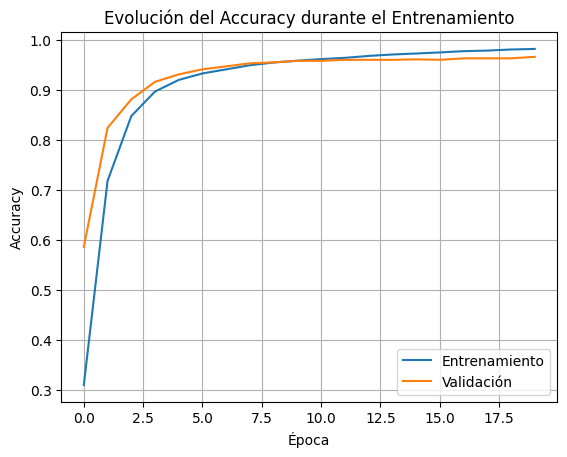

In [13]:
import matplotlib.pyplot as plt

# Graficar el Accuracy
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Evolución del Accuracy durante el Entrenamiento')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()